# Exercise 1: Linear Models, GAMs, and VARs

Audience:
- Students in the interpretable models chapter who already know linear regression and basic time-series notation.

Goal:
- Work through the same `stock` / `mkt` forecasting task with three models: a linear lag model, a spline GAM, and a VAR.

Important:
- Only edit cells marked `STUDENT IMPLEMENTATION` if you want to re-do the steps yourself.
- Each question is followed immediately by the short implementation used to solve it.
- Run the notebook with the course `ml` kernel/environment because the VAR section uses `statsmodels`.
- The dataset is already saved in `data/gam_var_finance_exercise_prices.csv`.


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler
from statsmodels.tsa.api import VAR

DATA_DIR = Path("data")
NOTEBOOK_SLUG = "gam_var_finance_exercise"
OUT_DIR = Path("out") / NOTEBOOK_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "gam_var_finance_exercise_prices.csv"

STOCK = "stock"
MKT = "mkt"
SERIES_COLORS = {STOCK: "tab:blue", MKT: "tab:orange"}
N_TEST = 12
EXAMPLE_STEP = 3

FEATURE_COLUMNS = (
    "target_lag1_return",
    "target_lag2_return",
    "peer_lag1_return",
    "peer_lag2_return",
)
FEATURE_LABELS = {
    "target_lag1_return": r"$r_{t-1}^{\mathrm{stock}}$",
    "target_lag2_return": r"$r_{t-2}^{\mathrm{stock}}$",
    "peer_lag1_return": r"$r_{t-1}^{\mathrm{mkt}}$",
    "peer_lag2_return": r"$r_{t-2}^{\mathrm{mkt}}$",
}

LINEAR_MODEL_LABEL = "Linear lag model"
GAM_MODEL_LABEL = "Spline GAM"
VAR_MODEL_LABEL = "VAR"
MODEL_COLORS = {
    "Observed": "0.45",
    LINEAR_MODEL_LABEL: "tab:orange",
    GAM_MODEL_LABEL: "tab:blue",
    VAR_MODEL_LABEL: "tab:cyan",
}

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.8),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
    }
)

def save_fig(fig, filename: str) -> Path:
    path = OUT_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight", transparent=True)
    print(f"saved: {path}")
    return path

def split_train_test(frame: pd.DataFrame, *, n_test: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    return frame.iloc[:-n_test].copy(), frame.iloc[-n_test:].copy()

def rebuild_price_path(last_observed_price, forecast_returns):
    return last_observed_price * np.exp(forecast_returns.cumsum())

def mean_absolute_percentage_error(actual: pd.Series, predicted: pd.Series) -> float:
    return float((np.abs(actual - predicted) / actual).mean() * 100)

def metric_row(
    model_label: str,
    actual_prices: pd.Series,
    predicted_prices: pd.Series,
    actual_returns: pd.Series,
    predicted_returns: pd.Series,
) -> dict[str, float | str]:
    return {
        "model": model_label,
        "price_MAPE_pct": mean_absolute_percentage_error(actual_prices, predicted_prices),
        "return_RMSE_bp": float(mean_squared_error(actual_returns, predicted_returns) ** 0.5 * 1e4),
    }


## Part 1: Prepare the Weekly Dataset


### Question 1: Load and inspect the weekly price data

The file at `DATA_PATH` already contains two aligned price series:
- `stock`: the target stock we want to forecast
- `mkt`: a peer or market-style reference series

Create a clean `prices` DataFrame indexed by date, sorted from oldest to newest, then make a simple line plot of both price paths.

Use:
- `pd.read_csv(..., parse_dates=["date"])`
- `.set_index("date")`
- `.sort_index()`
- `ax.plot(...)`


,stock,mkt
date,,
2018-01-01,1.000000,1.000000
2018-01-08,1.061881,1.053526
2018-01-15,1.053240,1.049860
2018-01-22,1.140676,1.307681
2018-01-29,1.163374,1.273537


,value
rows,105
columns,"[stock, mkt]"


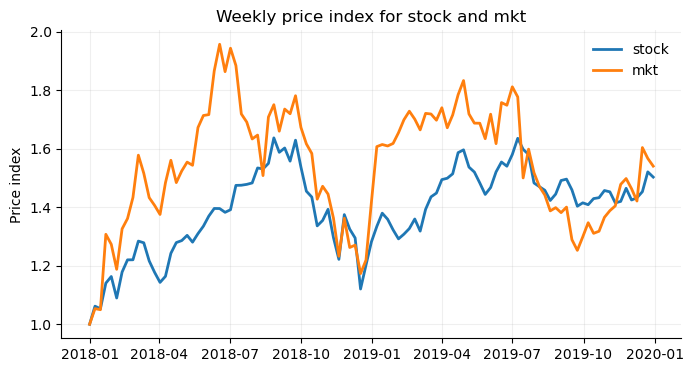

saved: out/gam_var_finance_exercise/exercise_price_indices.pdf


PosixPath('out/gam_var_finance_exercise/exercise_price_indices.pdf')

In [2]:
# STUDENT IMPLEMENTATION
prices = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()

display(prices.head())
display(pd.Series({"rows": len(prices), "columns": list(prices.columns)}, name="value").to_frame())

fig, ax = plt.subplots(figsize=(8, 4))
for column in prices.columns:
    ax.plot(prices.index, prices[column], linewidth=2, label=column, color=SERIES_COLORS[column])
ax.set_title("Weekly price index for stock and mkt")
ax.set_ylabel("Price index")
ax.legend(frameon=False)
plt.show()
save_fig(fig, "exercise_price_indices.pdf")


### Question 2: Compute weekly log returns

A one-period log return measures the relative price change from week `t-1` to week `t`:
$$
r_t = \log(P_t) - \log(P_{t-1}) = \log\!\left(\frac{P_t}{P_{t-1}}\right).
$$
We model returns rather than raw prices because returns are usually more stable and additive over time.

Implement `compute_log_returns(...)` and apply it to `prices` to create `log_returns` for both `stock` and `mkt`.

Use:
- `np.log(...)`
- `.diff()`
- `.dropna()`


In [3]:
# STUDENT IMPLEMENTATION

def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return np.log(prices).diff().dropna()

log_returns = compute_log_returns(prices)

display(log_returns.head())


,stock,mkt
date,,
2018-01-08,0.060041,0.052143
2018-01-15,-0.008170,-0.003487
2018-01-22,0.079749,0.219599
2018-01-29,0.019704,-0.026458
2018-02-05,-0.065268,-0.069519


### Question 3: Build the supervised lagged dataset

For each week `t`, predict the current stock return $r_t^{\mathrm{stock}}$ from four lagged inputs:
- $r_{t-1}^{\mathrm{stock}}$
- $r_{t-2}^{\mathrm{stock}}$
- $r_{t-1}^{\mathrm{mkt}}$
- $r_{t-2}^{\mathrm{mkt}}$

Implement `make_lagged_dataset(...)` so the output contains:
- the four lagged predictor columns
- `target_return`: the current stock return to predict
- `target_price`: the aligned stock price on the same date, needed later to rebuild a price path

Hint:
- Use `.shift(1)` and `.shift(2)` on the return series before calling `.dropna()`.


In [4]:
def make_lagged_dataset(prices: pd.DataFrame, log_returns: pd.DataFrame) -> pd.DataFrame:
    # STUDENT IMPLEMENTATION
    frame = pd.DataFrame(
        {
            "target_lag1_return": log_returns[STOCK].shift(1),
            "target_lag2_return": log_returns[STOCK].shift(2),
            "peer_lag1_return": log_returns[MKT].shift(1),
            "peer_lag2_return": log_returns[MKT].shift(2),
            "target_return": log_returns[STOCK],
        }
    ).dropna()
    frame["target_price"] = prices.loc[frame.index, STOCK]
    return frame

gam_dataset = make_lagged_dataset(prices, log_returns)
train_gam, test_gam = split_train_test(gam_dataset, n_test=N_TEST)

x_train = train_gam.loc[:, list(FEATURE_COLUMNS)]
y_train = train_gam["target_return"]
x_test = test_gam.loc[:, list(FEATURE_COLUMNS)]
y_test = test_gam["target_return"]

history_prices = prices[STOCK].loc[: train_gam.index[-1]]
actual_prices = test_gam["target_price"]
example_date = test_gam.index[EXAMPLE_STEP]

display(gam_dataset.head())
display(
    pd.Series(
        {
            "rows": len(gam_dataset),
            "train_rows": len(train_gam),
            "test_rows": len(test_gam),
            "example_date": str(example_date.date()),
        },
        name="value",
    ).to_frame()
)


,target_lag1_return,target_lag2_return,peer_lag1_return,peer_lag2_return,target_return,target_price
date,,,,,,
2018-01-22,-0.008170,0.060041,-0.003487,0.052143,0.079749,1.140676
2018-01-29,0.079749,-0.008170,0.219599,-0.003487,0.019704,1.163374
2018-02-05,0.019704,0.079749,-0.026458,0.219599,-0.065268,1.089868
2018-02-12,-0.065268,0.019704,-0.069519,-0.026458,0.078289,1.178621
2018-02-19,0.078289,-0.065268,0.110151,-0.069519,0.034805,1.220365


,value
rows,102
train_rows,90
test_rows,12
example_date,2019-11-04


## Part 2: Linear Lag Model


### Question 4: Fit a linear lag model and plot the held-out forecast

This model assumes that the next stock return is a weighted sum of the four lagged returns. Build a small `sklearn` pipeline that standardizes each feature and then fits `Ridge`.

Then:
- fit the model on the training part of the lagged dataset
- predict one-step-ahead returns on the test window
- convert the predicted returns back into a stock price path

Use:
- `ColumnTransformer`
- `StandardScaler`
- `Ridge`
- `Pipeline`


,value
model,Linear lag model
price_MAPE_pct,1.619408
return_RMSE_bp,178.751053


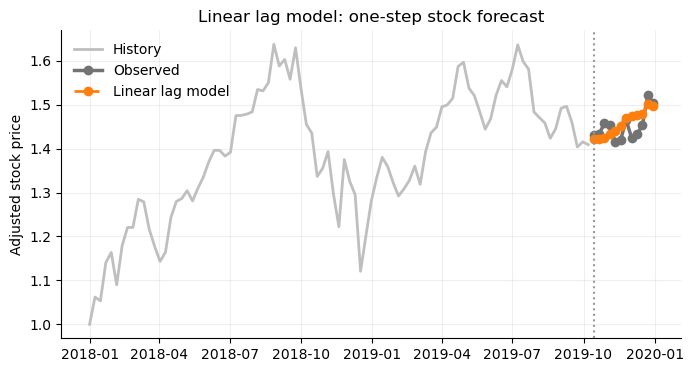

saved: out/gam_var_finance_exercise/exercise_linear_forecast.pdf


PosixPath('out/gam_var_finance_exercise/exercise_linear_forecast.pdf')

In [5]:
def make_linear_model(feature_columns: tuple[str, ...], alpha: float = 1.0) -> Pipeline:
    # STUDENT IMPLEMENTATION
    transformers = [(feature, StandardScaler(), [feature]) for feature in feature_columns]
    return Pipeline(
        [
            (
                "preprocessor",
                ColumnTransformer(
                    transformers,
                    remainder="drop",
                    verbose_feature_names_out=False,
                ),
            ),
            ("ridge", Ridge(alpha=alpha)),
        ]
    )

linear_model = make_linear_model(FEATURE_COLUMNS, alpha=1.0)
linear_model.fit(x_train, y_train)

linear_pred_returns = pd.Series(linear_model.predict(x_test), index=x_test.index, name="predicted_return")
linear_pred_prices = rebuild_price_path(history_prices.iloc[-1], linear_pred_returns)
linear_metrics = metric_row(
    LINEAR_MODEL_LABEL,
    actual_prices,
    linear_pred_prices,
    y_test,
    linear_pred_returns,
)

display(pd.Series(linear_metrics).to_frame("value"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_prices.index, history_prices, color="0.75", linewidth=2, label="History")
ax.plot(actual_prices.index, actual_prices, color=MODEL_COLORS["Observed"], linewidth=2.5, marker="o", label="Observed")
ax.plot(linear_pred_prices.index, linear_pred_prices, color=MODEL_COLORS[LINEAR_MODEL_LABEL], linewidth=2, linestyle="--", marker="o", label=LINEAR_MODEL_LABEL)
ax.axvline(actual_prices.index[0], color="0.6", linestyle=":")
ax.set_title("Linear lag model: one-step stock forecast")
ax.set_ylabel("Adjusted stock price")
ax.legend(frameon=False)
plt.show()
save_fig(fig, "exercise_linear_forecast.pdf")


### Question 5: Visualize the contribution weights for one linear forecast

Choose the provided `example_date`. For that date, decompose the linear prediction into:
- the intercept
- the contribution from each lagged feature

Because the model is linear, each feature contribution is the transformed feature value multiplied by its fitted coefficient. Plot the resulting contributions as a horizontal bar chart.

Use:
- `linear_model.named_steps[...]`
- `preprocessor.transform(...)`
- `ax.barh(...)`


,contribution
Intercept,0.003234
$r_{t-1}^{\mathrm{stock}}$,-0.001604
$r_{t-2}^{\mathrm{stock}}$,0.000145
$r_{t-1}^{\mathrm{mkt}}$,0.003942
$r_{t-2}^{\mathrm{mkt}}$,0.000073
Prediction,0.005790


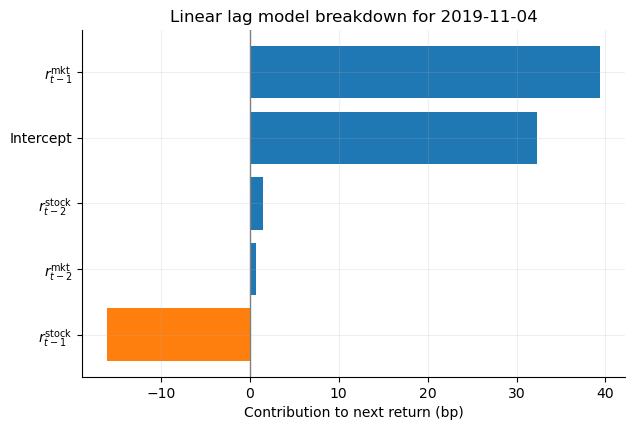

saved: out/gam_var_finance_exercise/exercise_linear_breakdown.pdf


PosixPath('out/gam_var_finance_exercise/exercise_linear_breakdown.pdf')

In [6]:
# STUDENT IMPLEMENTATION

def pipeline_contribution_breakdown(
    model: Pipeline,
    row: pd.Series,
    feature_columns: tuple[str, ...],
    feature_labels: dict[str, str],
) -> pd.Series:
    preprocessor = model.named_steps["preprocessor"]
    ridge = model.named_steps["ridge"]
    row_frame = row.loc[list(feature_columns)].to_frame().T
    transformed = preprocessor.transform(row_frame)
    if not isinstance(transformed, np.ndarray):
        transformed = transformed.toarray()

    contributions = {"Intercept": float(ridge.intercept_)}
    for feature in feature_columns:
        feature_slice = preprocessor.output_indices_[feature]
        contributions[feature_labels[feature]] = float(transformed[0, feature_slice] @ ridge.coef_[feature_slice])

    series = pd.Series(contributions, name="contribution")
    series["Prediction"] = float(series.sum())
    return series

linear_breakdown = pipeline_contribution_breakdown(
    linear_model,
    row=x_test.loc[example_date],
    feature_columns=FEATURE_COLUMNS,
    feature_labels=FEATURE_LABELS,
)

display(linear_breakdown.to_frame("contribution"))

values = linear_breakdown.drop("Prediction").sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(
    values.index,
    values.values * 1e4,
    color=["tab:orange" if value < 0 else "tab:blue" for value in values.values],
)
ax.axvline(0.0, color="0.5", linewidth=1)
ax.set_title(f"Linear lag model breakdown for {example_date:%Y-%m-%d}")
ax.set_xlabel("Contribution to next return (bp)")
plt.show()
save_fig(fig, "exercise_linear_breakdown.pdf")


## Part 3: Spline GAM


### Question 6: Fit a spline GAM and visualize its nonlinear effects

A GAM still adds separate feature effects, but each effect can now be nonlinear instead of a straight line. Replace the linear transformation with spline basis functions for each lagged feature, keep `Ridge` on top, and fit the model on the same training set.

Then make:
- a forecast plot comparing the linear model and the GAM
- a 2x2 panel of effect curves, one per lagged feature

Use:
- `SplineTransformer`
- `ColumnTransformer`
- `Ridge`
- `Pipeline`


,value
model,Spline GAM
price_MAPE_pct,1.540344
return_RMSE_bp,166.66456


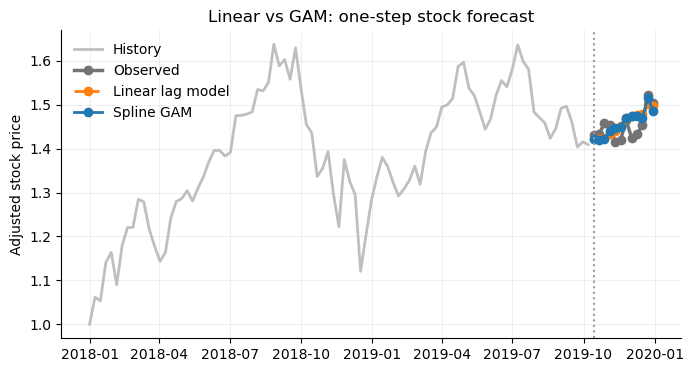

saved: out/gam_var_finance_exercise/exercise_linear_vs_gam_forecast.pdf


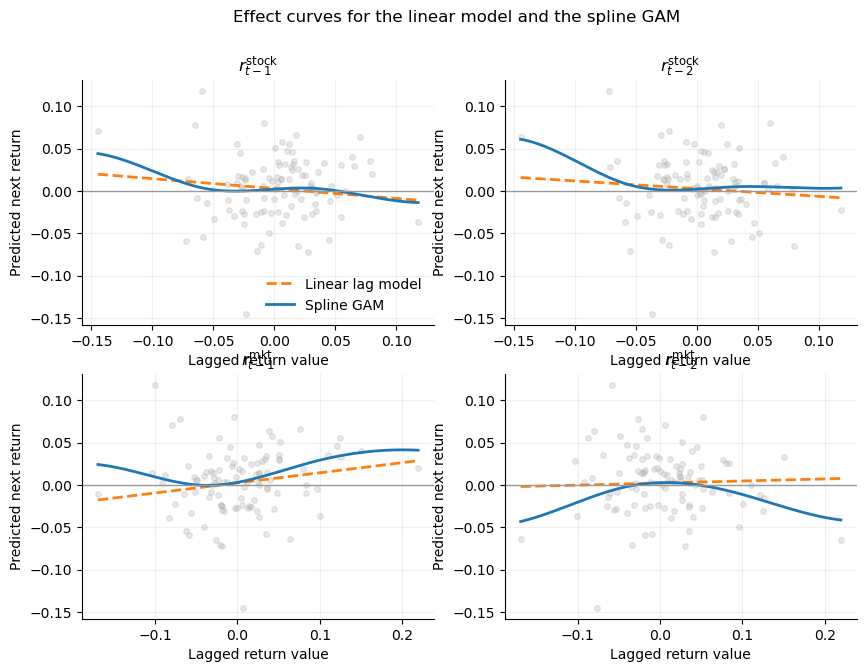

saved: out/gam_var_finance_exercise/exercise_gam_feature_effects.pdf


PosixPath('out/gam_var_finance_exercise/exercise_gam_feature_effects.pdf')

In [7]:
# STUDENT IMPLEMENTATION

def make_gam_model(feature_columns: tuple[str, ...], n_knots: int = 4, alpha: float = 0.3) -> Pipeline:
    transformers = [
        (
            feature,
            SplineTransformer(n_knots=n_knots, degree=3, include_bias=False),
            [feature],
        )
        for feature in feature_columns
    ]
    return Pipeline(
        [
            (
                "preprocessor",
                ColumnTransformer(
                    transformers,
                    remainder="drop",
                    verbose_feature_names_out=False,
                ),
            ),
            ("ridge", Ridge(alpha=alpha)),
        ]
    )


def effect_curve_frame(
    model: Pipeline,
    train_features: pd.DataFrame,
    feature_columns: tuple[str, ...],
    model_label: str,
) -> pd.DataFrame:
    anchor_row = train_features.median().to_frame().T
    rows = []
    for feature in feature_columns:
        grid = np.linspace(train_features[feature].min(), train_features[feature].max(), 160)
        grid_frame = pd.concat([anchor_row] * len(grid), ignore_index=True)
        grid_frame[feature] = grid
        rows.append(
            pd.DataFrame(
                {
                    "model": model_label,
                    "feature": feature,
                    "feature_value": grid,
                    "prediction": model.predict(grid_frame),
                }
            )
        )
    return pd.concat(rows, ignore_index=True)

gam_model = make_gam_model(FEATURE_COLUMNS, n_knots=4, alpha=0.3)
gam_model.fit(x_train, y_train)

gam_pred_returns = pd.Series(gam_model.predict(x_test), index=x_test.index, name="predicted_return")
gam_pred_prices = rebuild_price_path(history_prices.iloc[-1], gam_pred_returns)
gam_metrics = metric_row(
    GAM_MODEL_LABEL,
    actual_prices,
    gam_pred_prices,
    y_test,
    gam_pred_returns,
)

display(pd.Series(gam_metrics).to_frame("value"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_prices.index, history_prices, color="0.75", linewidth=2, label="History")
ax.plot(actual_prices.index, actual_prices, color=MODEL_COLORS["Observed"], linewidth=2.5, marker="o", label="Observed")
ax.plot(linear_pred_prices.index, linear_pred_prices, color=MODEL_COLORS[LINEAR_MODEL_LABEL], linewidth=2, linestyle="--", marker="o", label=LINEAR_MODEL_LABEL)
ax.plot(gam_pred_prices.index, gam_pred_prices, color=MODEL_COLORS[GAM_MODEL_LABEL], linewidth=2, marker="o", label=GAM_MODEL_LABEL)
ax.axvline(actual_prices.index[0], color="0.6", linestyle=":")
ax.set_title("Linear vs GAM: one-step stock forecast")
ax.set_ylabel("Adjusted stock price")
ax.legend(frameon=False)
plt.show()
save_fig(fig, "exercise_linear_vs_gam_forecast.pdf")

effect_curves = pd.concat(
    [
        effect_curve_frame(linear_model, x_train, FEATURE_COLUMNS, LINEAR_MODEL_LABEL),
        effect_curve_frame(gam_model, x_train, FEATURE_COLUMNS, GAM_MODEL_LABEL),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
for axis, feature in zip(axes, FEATURE_COLUMNS):
    axis.scatter(gam_dataset[feature], gam_dataset["target_return"], color="0.7", alpha=0.3, s=16)
    for model_label, linestyle in [(LINEAR_MODEL_LABEL, "--"), (GAM_MODEL_LABEL, "-")]:
        curve = effect_curves[(effect_curves["feature"] == feature) & (effect_curves["model"] == model_label)]
        axis.plot(curve["feature_value"], curve["prediction"], linewidth=2, linestyle=linestyle, color=MODEL_COLORS[model_label], label=model_label)
    axis.axhline(0.0, color="0.6", linewidth=1)
    axis.set_title(FEATURE_LABELS[feature])
    axis.set_xlabel("Lagged return value")
    axis.set_ylabel("Predicted next return")
axes[0].legend(frameon=False)
fig.suptitle("Effect curves for the linear model and the spline GAM")
plt.show()
save_fig(fig, "exercise_gam_feature_effects.pdf")


### Question 7: Visualize the contribution weights for one GAM forecast

Use the same `example_date` as before. Decompose the GAM prediction into:
- the intercept
- one total contribution per original lagged feature

Important:
- Each original feature expands into several spline basis columns.
- Sum those basis-level contributions back to the original feature before plotting, so the final bar chart stays interpretable.


,contribution
Intercept,0.011403
$r_{t-1}^{\mathrm{stock}}$,-0.005611
$r_{t-2}^{\mathrm{stock}}$,-0.019339
$r_{t-1}^{\mathrm{mkt}}$,-0.009495
$r_{t-2}^{\mathrm{mkt}}$,0.034886
Prediction,0.011844


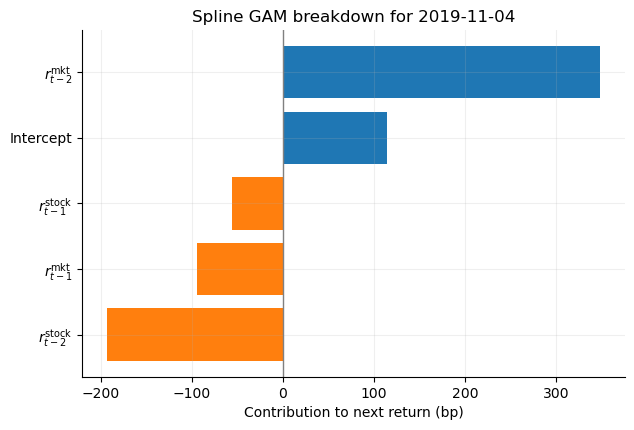

saved: out/gam_var_finance_exercise/exercise_gam_breakdown.pdf


PosixPath('out/gam_var_finance_exercise/exercise_gam_breakdown.pdf')

In [8]:
gam_breakdown = pipeline_contribution_breakdown(
    gam_model,
    row=x_test.loc[example_date],
    feature_columns=FEATURE_COLUMNS,
    feature_labels=FEATURE_LABELS,
)

display(gam_breakdown.to_frame("contribution"))

values = gam_breakdown.drop("Prediction").sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(
    values.index,
    values.values * 1e4,
    color=["tab:orange" if value < 0 else "tab:blue" for value in values.values],
)
ax.axvline(0.0, color="0.5", linewidth=1)
ax.set_title(f"Spline GAM breakdown for {example_date:%Y-%m-%d}")
ax.set_xlabel("Contribution to next return (bp)")
plt.show()
save_fig(fig, "exercise_gam_breakdown.pdf")


## Part 4: VAR


### Question 8: Fit a rolling one-step VAR and plot the held-out forecast

A VAR predicts the two-dimensional return vector
\[
\begin{bmatrix}
r_t^{\mathrm{stock}} \\
r_t^{\mathrm{mkt}}
\end{bmatrix}
\]
from past values of both series. This means the next stock return may depend on past `stock` returns and past `mkt` returns, and the same is true for the next `mkt` return.

Implement a small rolling forecast routine that:
1. selects a lag using a short validation backtest,
2. fits `VAR(...).fit(lag)` on the available history,
3. calls `.forecast(...)` one step ahead,
4. updates the history and repeats across the test window.

Then plot the held-out stock price forecast produced by the VAR.


selected lag: 3


/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-

,lag,validation_price_rmse,validation_return_rmse,bic
0,3,0.083766,0.032096,-12.022732
1,5,0.070598,0.032777,-11.612800
2,1,0.105230,0.032793,-12.288404
3,4,0.097617,0.032995,-11.782829
4,2,0.103179,0.033287,-12.069956
5,6,0.075450,0.035814,-11.457738


,value
model,VAR
price_MAPE_pct,1.694187
return_RMSE_bp,177.176729


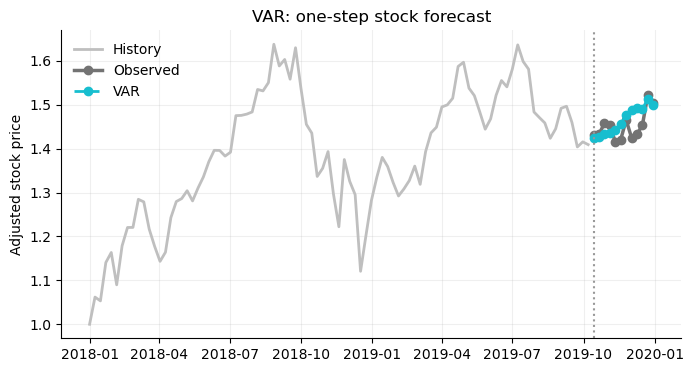

saved: out/gam_var_finance_exercise/exercise_var_forecast.pdf


PosixPath('out/gam_var_finance_exercise/exercise_var_forecast.pdf')

In [9]:
# STUDENT IMPLEMENTATION

def rolling_one_step_var_forecast(
    train_returns: pd.DataFrame,
    future_returns: pd.DataFrame,
    *,
    lag: int,
) -> pd.DataFrame:
    history = train_returns.copy()
    predictions = []
    for timestamp in future_returns.index:
        fitted = VAR(history).fit(lag)
        prediction = fitted.forecast(history.values[-lag:], steps=1)[0]
        predictions.append(prediction)
        history.loc[timestamp] = future_returns.loc[timestamp]
    return pd.DataFrame(predictions, index=future_returns.index, columns=train_returns.columns)


def lag_backtest_table(
    prices: pd.DataFrame,
    log_returns: pd.DataFrame,
    *,
    n_test: int,
    validation_size: int,
    maxlags: int,
) -> tuple[pd.DataFrame, int]:
    train_full, _ = split_train_test(log_returns, n_test=n_test)
    validation_size = min(validation_size, max(4, len(train_full) // 4))
    train_core = train_full.iloc[:-validation_size].copy()
    validation = train_full.iloc[-validation_size:].copy()
    last_core_price = prices.loc[train_core.index[-1]]
    actual_validation_prices = prices.loc[validation.index]

    candidate_maxlag = min(maxlags, max(1, len(train_core) // 5))
    rows = []
    for lag in range(1, candidate_maxlag + 1):
        fitted = VAR(train_core).fit(lag)
        validation_pred_returns = rolling_one_step_var_forecast(train_core, validation, lag=lag)
        validation_pred_prices = rebuild_price_path(last_core_price, validation_pred_returns)
        rows.append(
            {
                "lag": lag,
                "validation_price_rmse": float(np.sqrt(((actual_validation_prices - validation_pred_prices) ** 2).mean().mean())),
                "validation_return_rmse": float(np.sqrt(((validation - validation_pred_returns) ** 2).mean().mean())),
                "bic": float(fitted.bic),
            }
        )

    frame = pd.DataFrame(rows).sort_values(["validation_return_rmse", "bic", "lag"]).reset_index(drop=True)
    selected_lag = int(frame.iloc[0]["lag"])
    return frame, selected_lag

train_var, test_var = split_train_test(log_returns, n_test=N_TEST)
lag_table, selected_lag = lag_backtest_table(
    prices,
    log_returns,
    n_test=N_TEST,
    validation_size=8,
    maxlags=6,
)
var_pred_returns = rolling_one_step_var_forecast(train_var, test_var, lag=selected_lag)
var_pred_prices = rebuild_price_path(prices.loc[train_var.index[-1]], var_pred_returns)
var_metrics = metric_row(
    VAR_MODEL_LABEL,
    prices.loc[test_var.index, STOCK],
    var_pred_prices.loc[test_var.index, STOCK],
    test_var[STOCK],
    var_pred_returns[STOCK],
)

print(f"selected lag: {selected_lag}")
display(lag_table)
display(pd.Series(var_metrics).to_frame("value"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_prices.index, history_prices, color="0.75", linewidth=2, label="History")
ax.plot(actual_prices.index, actual_prices, color=MODEL_COLORS["Observed"], linewidth=2.5, marker="o", label="Observed")
ax.plot(var_pred_prices.index, var_pred_prices[STOCK], color=MODEL_COLORS[VAR_MODEL_LABEL], linewidth=2, linestyle="--", marker="o", label=VAR_MODEL_LABEL)
ax.axvline(actual_prices.index[0], color="0.6", linestyle=":")
ax.set_title("VAR: one-step stock forecast")
ax.set_ylabel("Adjusted stock price")
ax.legend(frameon=False)
plt.show()
save_fig(fig, "exercise_var_forecast.pdf")


### Question 9: Visualize the contribution weights for the VAR on the same date

For the same `example_date`, decompose the VAR prediction for `stock` into:
- the intercept
- contributions from lagged `stock` returns
- contributions from lagged `mkt` returns

Read the terms directly from the fitted VAR object:
- `fitted.intercept`
- `fitted.coefs`

Then make a horizontal bar chart of the resulting contributions.


/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


,contribution
Intercept,0.003410
$r_{t-1}^{\mathrm{stock}}$,-0.002106
$r_{t-1}^{\mathrm{mkt}}$,0.004405
$r_{t-2}^{\mathrm{stock}}$,-0.000309
$r_{t-2}^{\mathrm{mkt}}$,0.000161
$r_{t-3}^{\mathrm{stock}}$,-0.002111
$r_{t-3}^{\mathrm{mkt}}$,-0.002439
Prediction,0.001011


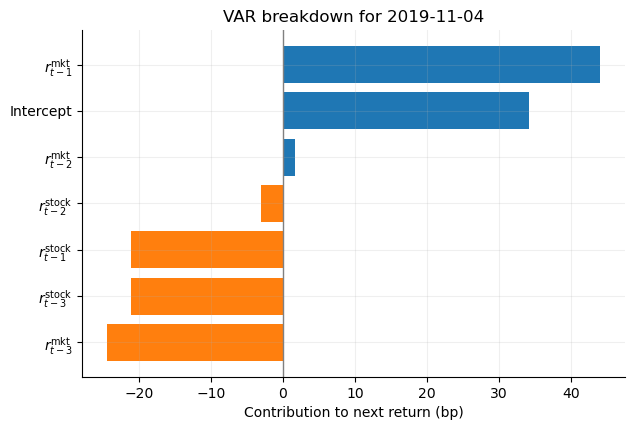

saved: out/gam_var_finance_exercise/exercise_var_breakdown.pdf


PosixPath('out/gam_var_finance_exercise/exercise_var_breakdown.pdf')

In [10]:
# STUDENT IMPLEMENTATION

def rolling_var_contribution_breakdown(
    train_returns: pd.DataFrame,
    future_returns: pd.DataFrame,
    *,
    lag: int,
    target: str,
    step_index: int,
) -> pd.Series:
    history = train_returns.copy()
    for offset, timestamp in enumerate(future_returns.index):
        fitted = VAR(history).fit(lag)
        if offset == step_index:
            target_index = fitted.names.index(target)
            contributions = {"Intercept": float(fitted.intercept[target_index])}
            for lag_number in range(1, fitted.k_ar + 1):
                observation = history.iloc[-lag_number]
                for source in fitted.names:
                    source_index = fitted.names.index(source)
                    coefficient = fitted.coefs[lag_number - 1, target_index, source_index]
                    label = rf"$r_{{t-{lag_number}}}^{{\mathrm{{{source}}}}}$"
                    contributions[label] = float(coefficient * observation[source])
            series = pd.Series(contributions, name="contribution")
            series["Prediction"] = float(series.sum())
            return series
        history.loc[timestamp] = future_returns.loc[timestamp]
    raise RuntimeError("step_index out of range")

var_breakdown = rolling_var_contribution_breakdown(
    train_var,
    test_var,
    lag=selected_lag,
    target=STOCK,
    step_index=int(test_var.index.get_loc(example_date)),
)

display(var_breakdown.to_frame("contribution"))

values = var_breakdown.drop("Prediction").sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(
    values.index,
    values.values * 1e4,
    color=["tab:orange" if value < 0 else "tab:blue" for value in values.values],
)
ax.axvline(0.0, color="0.5", linewidth=1)
ax.set_title(f"VAR breakdown for {example_date:%Y-%m-%d}")
ax.set_xlabel("Contribution to next return (bp)")
plt.show()
save_fig(fig, "exercise_var_breakdown.pdf")


## Part 5: Final Comparison


### Question 10: Compare the three models on the held-out window

Build a small comparison summary for the linear model, the GAM, and the VAR.

Make:
- one table with the metrics
- one figure comparing `price_MAPE_pct` and `return_RMSE_bp`
- one two-panel forecast figure with the full history on the left and the test window on the right

Goal:
- Check whether nonlinear marginal effects (GAM) or joint multivariate dynamics (VAR) improve over the simple linear lag model.


,model,price_MAPE_pct,return_RMSE_bp
0,Linear lag model,1.619,178.751
1,Spline GAM,1.540,166.665
2,VAR,1.694,177.177


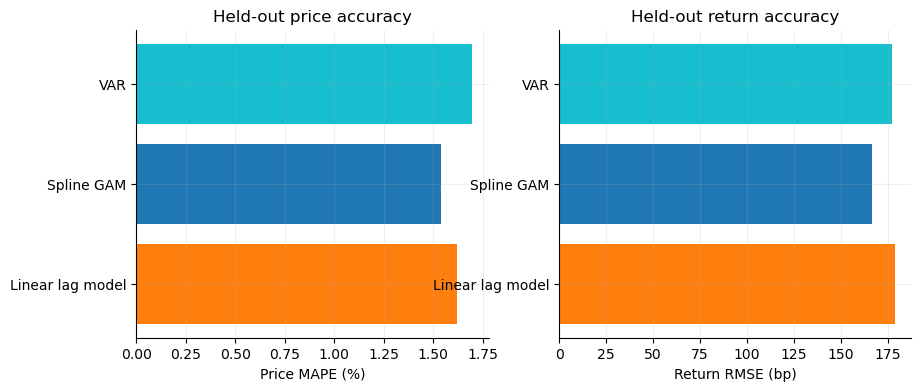

saved: out/gam_var_finance_exercise/exercise_model_comparison.pdf


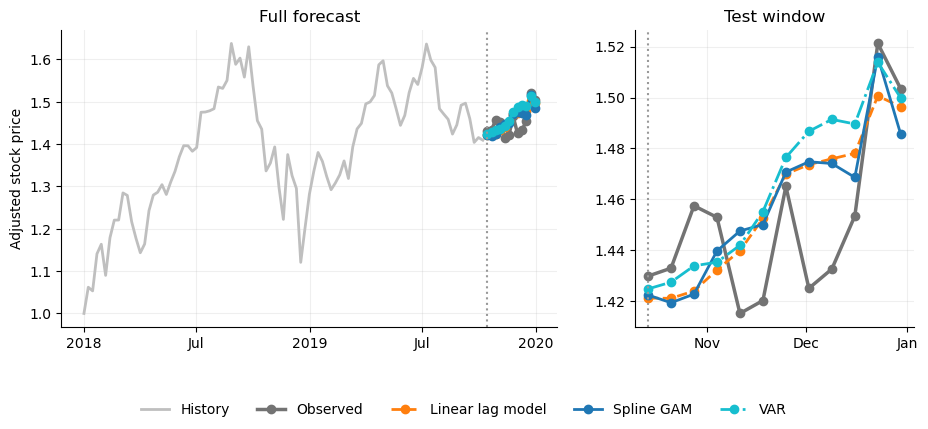

saved: out/gam_var_finance_exercise/exercise_forecast_panels.pdf


PosixPath('out/gam_var_finance_exercise/exercise_forecast_panels.pdf')

In [11]:
comparison_metrics = pd.DataFrame([linear_metrics, gam_metrics, var_metrics])
display(comparison_metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].barh(comparison_metrics["model"], comparison_metrics["price_MAPE_pct"], color=[MODEL_COLORS[LINEAR_MODEL_LABEL], MODEL_COLORS[GAM_MODEL_LABEL], MODEL_COLORS[VAR_MODEL_LABEL]])
axes[0].set_title("Held-out price accuracy")
axes[0].set_xlabel("Price MAPE (%)")

axes[1].barh(comparison_metrics["model"], comparison_metrics["return_RMSE_bp"], color=[MODEL_COLORS[LINEAR_MODEL_LABEL], MODEL_COLORS[GAM_MODEL_LABEL], MODEL_COLORS[VAR_MODEL_LABEL]])
axes[1].set_title("Held-out return accuracy")
axes[1].set_xlabel("Return RMSE (bp)")
plt.show()
save_fig(fig, "exercise_model_comparison.pdf")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [1.6, 0.9]})

axes[0].plot(history_prices.index, history_prices, color="0.75", linewidth=2, label="History")
axes[0].plot(actual_prices.index, actual_prices, color=MODEL_COLORS["Observed"], linewidth=2.5, marker="o", label="Observed")
axes[0].plot(linear_pred_prices.index, linear_pred_prices, color=MODEL_COLORS[LINEAR_MODEL_LABEL], linewidth=2, linestyle="--", marker="o", label=LINEAR_MODEL_LABEL)
axes[0].plot(gam_pred_prices.index, gam_pred_prices, color=MODEL_COLORS[GAM_MODEL_LABEL], linewidth=2, marker="o", label=GAM_MODEL_LABEL)
axes[0].plot(var_pred_prices.index, var_pred_prices[STOCK], color=MODEL_COLORS[VAR_MODEL_LABEL], linewidth=2, linestyle="-.", marker="o", label=VAR_MODEL_LABEL)
axes[0].axvline(actual_prices.index[0], color="0.6", linestyle=":")
axes[0].set_title("Full forecast")
axes[0].set_ylabel("Adjusted stock price")

axes[1].plot(actual_prices.index, actual_prices, color=MODEL_COLORS["Observed"], linewidth=2.5, marker="o")
axes[1].plot(linear_pred_prices.index, linear_pred_prices, color=MODEL_COLORS[LINEAR_MODEL_LABEL], linewidth=2, linestyle="--", marker="o")
axes[1].plot(gam_pred_prices.index, gam_pred_prices, color=MODEL_COLORS[GAM_MODEL_LABEL], linewidth=2, marker="o")
axes[1].plot(var_pred_prices.index, var_pred_prices[STOCK], color=MODEL_COLORS[VAR_MODEL_LABEL], linewidth=2, linestyle="-.", marker="o")
axes[1].axvline(actual_prices.index[0], color="0.6", linestyle=":")
axes[1].set_title("Test window")
axes[1].set_xlim(actual_prices.index[0] - pd.Timedelta(days=4), actual_prices.index[-1] + pd.Timedelta(days=4))

full_locator = mdates.AutoDateLocator(minticks=4, maxticks=6)
axes[0].xaxis.set_major_locator(full_locator)
axes[0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(full_locator))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
fig.subplots_adjust(bottom=0.22, wspace=0.2)
plt.show()
save_fig(fig, "exercise_forecast_panels.pdf")


## Reflection

- Which lagged effect looks most nonlinear in the GAM effect curves?
- On the selected forecast date, which contribution plot is easiest to interpret: linear, GAM, or VAR?
- If you had to explain one forecast to a non-technical stakeholder, which model would you choose and why?


In [12]:
# Optional notes for yourself.
